# Credit Risk Default — Feature Engineering


Do not train models here. This notebook is for feature ideas only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Load cleaned data

In [2]:
import os
print(os.getcwd())

import pandas as pd

# Load the cleaned train and test sets
# parse_dates ensures earliest_cr_line comes back as a datetime, not a string
train_final = pd.read_csv('../data/processed/train_cleaned_accepted_loans.csv', parse_dates=['earliest_cr_line'])
test_final = pd.read_csv('../data/processed/test_cleaned_accepted_loans.csv', parse_dates=['earliest_cr_line'])

# Split back into X (features) and y (target), same as before saving
X_train = train_final.drop(columns=['loan_status'])
y_train = train_final['loan_status']

X_test = test_final.drop(columns=['loan_status'])
y_test = test_final['loan_status']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

c:\Users\Marienne\OneDrive\Documents\personal project\BuildersLab project\credict risk prediction\Credit-Risk-Default\notebooks
X_train shape: (1093451, 126)
y_train shape: (1093451,)
X_test shape: (273366, 126)
y_test shape: (273366,)


## Feature engineering

In [3]:
# SUSPICIOUS OUTLIERS — CREATE INVESTIGATION FLAGS

for split in [X_train, X_test]:
    # annual_inc: max is $10,999,200 which is almost $11M
    # extremely unlikely for a personal loan platform
    # flag incomes above $500k as suspicious outliers for investigation
    split['annual_inc_flag'] = (split['annual_inc'] > 500000).astype(int)

    # revol_bal: max is $2,904,836 which is nearly $3M revolving balance
    # flag balances above $500k as suspicious
    split['revol_bal_flag'] = (split['revol_bal'] > 500000).astype(int)

    # tot_coll_amt: max is $9,152,545 which is extremely high for collection amount
    # flag amounts above $100k as suspicious
    split['tot_coll_amt_flag'] = (split['tot_coll_amt'] > 100000).astype(int)

    # mths_since_rcnt_il: max is 511 months (42+ years) which is suspicious
    # flag values above 300 months (25 years) as suspicious
    split['mths_since_rcnt_il_flag'] = (split['mths_since_rcnt_il'] > 300).astype(int)

    # mths_since_recent_bc: max is 639 months (53+ years) which is suspicious
    # flag values above 300 months as suspicious
    split['mths_since_recent_bc_flag'] = (split['mths_since_recent_bc'] > 300).astype(int)

    # mo_sin_rcnt_rev_tl_op: max is 438 months (36+ years) which is suspicious
    # flag values above 300 months as suspicious
    split['mo_sin_rcnt_rev_tl_op_flag'] = (split['mo_sin_rcnt_rev_tl_op'] > 300).astype(int)

    # mo_sin_rcnt_tl: max is 314 months (26+ years) which is suspicious
    # flag values above 300 months as suspicious
    split['mo_sin_rcnt_tl_flag'] = (split['mo_sin_rcnt_tl'] > 300).astype(int)

    # earliest_cr_line: some dates go back to 1934 which means the borrower
    # would be 80+ years old, likely a data entry error
    # flag credit lines opened before 1950 as suspicious
    split['earliest_cr_line_flag'] = (split['earliest_cr_line'].dt.year < 1950).astype(int)

    # delinq_amnt: max is $249,925 with a mean of only $14.92
    # extreme outlier, flag amounts above $10,000 for investigation
    split['delinq_amnt_flag'] = (split['delinq_amnt'] > 10000).astype(int)

C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\1335056866.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['annual_inc_flag'] = (split['annual_inc'] > 500000).astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\1335056866.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['revol_bal_flag'] = (split['revol_bal'] > 500000).astype(int)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\1335056866.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [4]:
#Currently you have fico_range_low and fico_range_high as two separate columns. They always differ by exactly 4 points so keeping both is redundant.

#FICO Score Features
for split in [X_train, X_test]:
    # fico_avg: single clean credit score instead of two near-identical columns
    # the midpoint is the most honest representation of the borrower's score
    split['fico_avg'] = (split['fico_range_low'] + split['fico_range_high']) / 2

    # fico_risk_bucket: group scores into standard credit risk categories
    # this captures non-linear relationships that a model might miss
    # (difference between 580 and 620 is much more meaningful than 750 vs 790)
    def fico_bucket(score):
        if score >= 800:
            return 'exceptional'
        elif score >= 740:
            return 'very_good'
        elif score >= 670:
            return 'good'
        elif score >= 580:
            return 'fair'
        else:
            return 'poor'

    split['fico_risk_bucket'] = split['fico_avg'].apply(fico_bucket)

    # drop the original two columns since fico_avg replaces them
    split.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

print("FICO features created")
print(X_train['fico_risk_bucket'].value_counts())
print(X_train['fico_avg'].describe())

C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\2190768733.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['fico_avg'] = (split['fico_range_low'] + split['fico_range_high']) / 2
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\2190768733.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['fico_risk_bucket'] = split['fico_avg'].apply(fico_bucket)


FICO features created
fico_risk_bucket
good           781853
fair           193829
very_good      105237
exceptional     12532
Name: count, dtype: int64
count    1.093451e+06
mean     6.981264e+02
std      3.184117e+01
min      6.270000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.120000e+02
max      8.475000e+02
Name: fico_avg, dtype: float64


In [5]:
#Ratio Features
#These combine two existing columns into a single more meaningful ratio.
#Why ratios are powerful: A person borrowing $10,000 with a $200,000 income is very different from a person borrowing $10,000 with a $15,000 income. The raw loan amount alone does not tell you that — but the ratio does.

for split in [X_train, X_test]:
    # loan_to_income: what percentage of annual income is being borrowed
    # high ratio = borrower is taking on a lot relative to their earnings
    # +1 avoids division by zero for the rare annual_inc = 0 cases
    split['loan_to_income'] = split['loan_amnt'] / (split['annual_inc'] + 1)

    # revol_bal_to_income: revolving debt relative to annual income
    # shows how much existing debt burden the borrower is carrying
    # +1 avoids division by zero for the rare annual_inc = 0 cases
    split['revol_bal_to_income'] = split['revol_bal'] / (split['annual_inc'] + 1)

    # total_debt_to_income: combines dti concept with actual balance
    # more complete picture of debt burden than dti alone
    split['total_debt_to_income'] = split['tot_cur_bal'] / (split['annual_inc'] + 1)
    # +1 avoids division by zero for the rare annual_inc = 0 cases

    # open_acc_ratio: proportion of total accounts that are still open
    # shows how active the borrower's credit profile is
    split['open_acc_ratio'] = split['open_acc'] / (split['total_acc'] + 1)

    # delinq_to_acc_ratio: proportion of accounts ever delinquent
    # directly measures historical repayment problems
    split['delinq_to_acc_ratio'] = split['num_accts_ever_120_pd'] / (split['total_acc'] + 1)

print("Ratio features created successfully")
print(X_train[['loan_to_income', 'revol_bal_to_income',
          'total_debt_to_income', 'open_acc_ratio',
          'delinq_to_acc_ratio']].describe())

C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\1754194264.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['loan_to_income'] = split['loan_amnt'] / (split['annual_inc'] + 1)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\1754194264.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['revol_bal_to_income'] = split['revol_bal'] / (split['annual_inc'] + 1)
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\1754194264.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

Ratio features created successfully
       loan_to_income  revol_bal_to_income  total_debt_to_income  \
count    1.093451e+06         1.093451e+06          1.093451e+06   
mean     5.275554e+00         4.822299e+00          4.096763e+01   
std      3.497678e+02         6.946087e+02          3.651302e+03   
min      1.714285e-04         0.000000e+00          0.000000e+00   
25%      1.249969e-01         9.806985e-02          5.362303e-01   
50%      1.999959e-01         1.791584e-01          1.254864e+00   
75%      2.916626e-01         2.952568e-01          2.760581e+00   
max      4.000000e+04         6.091310e+05          1.339445e+06   

       open_acc_ratio  delinq_to_acc_ratio  
count    1.093451e+06         1.093451e+06  
mean     4.761930e-01         1.855623e-02  
std      1.600556e-01         4.696491e-02  
min      0.000000e+00         0.000000e+00  
25%      3.571429e-01         0.000000e+00  
50%      4.615385e-01         0.000000e+00  
75%      5.833333e-01         0.0000

In [6]:
print(X_train['issue_d'].dtype)
print(X_train['earliest_cr_line'].dtype)

str
datetime64[us]


In [7]:
for split in [X_train, X_test]:
    split['issue_d'] = pd.to_datetime(split['issue_d'])
    split['earliest_cr_line'] = pd.to_datetime(split['earliest_cr_line'])

In [8]:
for split in [X_train, X_test]:
    split['credit_age'] = (split['issue_d'] - split['earliest_cr_line']).dt.days / 365

C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\4026766953.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['credit_age'] = (split['issue_d'] - split['earliest_cr_line']).dt.days / 365
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\4026766953.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split['credit_age'] = (split['issue_d'] - split['earliest_cr_line']).dt.days / 365


## Temporal features

TODO: extract hour, day of week, month etc. from the timestamp column.  
Explain why each feature is expected to be predictive.

In [9]:
date_cols = X_train.select_dtypes(include=['datetime64[ns]']).columns

for col in date_cols:
    X_train[f'{col}_year'] = X_train[col].dt.year
    X_train[f'{col}_month'] = X_train[col].dt.month
    X_train[f'{col}_day'] = X_train[col].dt.day

    X_test[f'{col}_year'] = X_test[col].dt.year
    X_test[f'{col}_month'] = X_test[col].dt.month
    X_test[f'{col}_day'] = X_test[col].dt.day

    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\600013609.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[f'{col}_year'] = X_train[col].dt.year
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\600013609.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[f'{col}_month'] = X_train[col].dt.month
C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\600013609.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

## Feature selection

In [10]:
# Drop emp_title column since it has too many unique values to be useful
X_train = X_train.drop(columns=['emp_title'])
X_test = X_test.drop(columns=['emp_title'])

In [11]:
# Check cardinality (unique value count) of all object/category columns
object_cols = X_train.select_dtypes(include=['object', 'category']).columns
for col in object_cols:
    print(col, X_train[col].nunique())

C:\Users\Marienne\AppData\Local\Temp\ipykernel_23872\963081669.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = X_train.select_dtypes(include=['object', 'category']).columns


home_ownership 4
verification_status 3
url 1093451
desc 97750
purpose 14
title 50987
zip_code 939
addr_state 51
initial_list_status 2
application_type 2
verification_status_joint 4
hardship_type 1
disbursement_method 2
fico_risk_bucket 4


url should just be dropped — it's an identifier, not predictive information.

desc and title are free text. Dropping them for now is the simplest fix. If you want to use them later, that requires NLP techniques (e.g. TF-IDF, embeddings, or simple keyword extraction) — not one-hot encoding — and would be a separate feature engineering step, not something to solve right now.

In [12]:
cols_to_drop = ['url', 'desc', 'title']

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [13]:
# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Make sure both datasets have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [14]:
# Columns where almost everyone has the same value tell the model nothing.
from sklearn.feature_selection import VarianceThreshold

# select only numeric columns for variance check (include bool since get_dummies produces bool columns)
numeric_cols = X_train.select_dtypes(include=['float64', 'int64', 'Int64', 'bool']).columns.tolist()

# calculate variance for each column — TRAIN ONLY
variances = X_train[numeric_cols].var().sort_values()

# show columns with very low variance
low_variance = variances[variances < 0.01]
print(f"Columns with near-zero variance: {len(low_variance)}")
print(low_variance)

Columns with near-zero variance: 992
policy_code        0.000000e+00
deferral_term      0.000000e+00
hardship_length    0.000000e+00
zip_code_889xx     9.145357e-07
zip_code_353xx     9.145357e-07
                       ...     
zip_code_331xx     8.394194e-03
zip_code_300xx     8.993490e-03
addr_state_OK      9.041078e-03
zip_code_606xx     9.094946e-03
addr_state_KY      9.470955e-03
Length: 992, dtype: float64


In [ ]:
#High Correlation Between Features
import seaborn as sns
import matplotlib.pyplot as plt

# calculate correlation matrix for numeric columns — TRAIN ONLY
corr_matrix = X_train[numeric_cols].corr().abs()

# find pairs with correlation above 0.90
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [
    (col, row, upper_triangle.loc[row, col])
    for col in upper_triangle.columns
    for row in upper_triangle.index
    if upper_triangle.loc[row, col] > 0.90
]

print(f"Highly correlated pairs (>0.90): {len(high_corr_pairs)}")
for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f"  {col1} vs {col2}: {corr:.4f}")

In [15]:
#Correlation With Target
# calculate correlation of each feature with target — TRAIN ONLY
target_corr = X_train[numeric_cols].corrwith(y_train).abs().sort_values(ascending=False)

print("Top 20 features most correlated with target:")
print(target_corr.head(20))

print("\nBottom 20 features least correlated with target:")
print(target_corr.tail(20))

# features with near-zero correlation with target
weak_features = target_corr[target_corr < 0.01]
print(f"\nFeatures with < 0.01 correlation with target: {len(weak_features)}")
print(weak_features)

c:\Users\Marienne\OneDrive\Documents\personal project\BuildersLab project\credict risk prediction\Credit-Risk-Default\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Marienne\OneDrive\Documents\personal project\BuildersLab project\credict risk prediction\Credit-Risk-Default\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 20 features most correlated with target:
term                            0.182217
fico_avg                        0.129013
dti                             0.106145
acc_open_past_24mths            0.099361
id                              0.088648
num_tl_op_past_12m              0.084277
fico_risk_bucket_very_good      0.080780
credit_bureau_data_available    0.079441
mort_acc                        0.075879
bc_open_to_buy                  0.075065
open_rv_24m                     0.073730
tot_hi_cred_lim                 0.073650
avg_cur_bal                     0.073620
loan_amnt                       0.073001
fico_risk_bucket_fair           0.071087
num_actv_rev_tl                 0.069833
num_rev_tl_bal_gt_0             0.067987
total_bc_limit                  0.067071
home_ownership_RENT             0.066343
tot_cur_bal                     0.065537
dtype: float64

Bottom 20 features least correlated with target:
zip_code_467xx     0.000045
zip_code_248xx     0.000045
zip_code_927xx

In [16]:

#Drop based on filter results
cols_to_drop = []
# 1. near zero variance columns
cols_to_drop.extend(low_variance.index.tolist())
# 2. from high correlation pairs - drop the second column in each pair
# since the first one captures the same information
#high_corr_to_drop = list(set([col2 for col1, col2, corr in high_corr_pairs]))
#cols_to_drop.extend(high_corr_to_drop)
# 3. weak correlation with target
cols_to_drop.extend(weak_features.index.tolist())

print(f"Total columns to drop from filter methods: {len(cols_to_drop)}")
print(cols_to_drop)

# drop from both splits
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)
print(f"\nTrain shape after filter selection: {X_train.shape}")
print(f"Test shape after filter selection : {X_test.shape}")

Total columns to drop from filter methods: 2017
['policy_code', 'deferral_term', 'hardship_length', 'zip_code_889xx', 'zip_code_353xx', 'zip_code_269xx', 'zip_code_858xx', 'zip_code_888xx', 'zip_code_205xx', 'zip_code_817xx', 'zip_code_742xx', 'zip_code_520xx', 'zip_code_509xx', 'zip_code_568xx', 'zip_code_429xx', 'zip_code_849xx', 'zip_code_340xx', 'zip_code_525xx', 'zip_code_516xx', 'zip_code_862xx', 'mo_sin_rcnt_tl_flag', 'zip_code_698xx', 'zip_code_819xx', 'zip_code_643xx', 'zip_code_649xx', 'zip_code_621xx', 'zip_code_682xx', 'zip_code_964xx', 'zip_code_938xx', 'zip_code_892xx', 'zip_code_095xx', 'zip_code_093xx', 'zip_code_522xx', 'zip_code_511xx', 'zip_code_872xx', 'zip_code_524xx', 'mo_sin_old_il_acct_flag', 'zip_code_694xx', 'zip_code_375xx', 'zip_code_896xx', 'zip_code_552xx', 'zip_code_909xx', 'zip_code_663xx', 'zip_code_929xx', 'zip_code_709xx', 'zip_code_901xx', 'zip_code_343xx', 'zip_code_501xx', 'zip_code_504xx', 'zip_code_523xx', 'zip_code_204xx', 'zip_code_510xx', 'tot

In [19]:
print('df.columns:', X_train.columns.tolist())

df.columns: ['id', 'member_id', 'loan_amnt', 'term', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'annual_inc_joint', 'dti_joint', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_op_rev_tl', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bc_limit', 'revol_bal_joint', 'sec_app_fico

In [20]:
cols_to_drop = ['id', 'member_id']

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))  # should be True after align()

(1093451, 104)
(273366, 104)
True


## FEATURE SELECTION THROUGHT MODELS RUNNING

In [25]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Use class_weight to account for your imbalance (from earlier)
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # use all CPU cores to speed this up
)

rf.fit(X_train, y_train)

# Get feature importances
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(30))

                   feature  importance
1                     term    0.036281
3                      dti    0.035980
0                loan_amnt    0.031748
2               annual_inc    0.028661
9               revol_util    0.027155
31          bc_open_to_buy    0.027149
54         tot_hi_cred_lim    0.026830
30             avg_cur_bal    0.026515
76                fico_avg    0.026200
8                revol_bal    0.026183
14             tot_cur_bal    0.026015
77          open_acc_ratio    0.025904
78              credit_age    0.025486
55          total_bc_limit    0.024980
25        total_rev_hi_lim    0.024508
32                 bc_util    0.024319
34    mo_sin_old_rev_tl_op    0.024084
33      mo_sin_old_il_acct    0.024047
38    mths_since_recent_bc    0.021476
10               total_acc    0.021426
82   earliest_cr_line_year    0.018372
39   mths_since_recent_inq    0.017957
35   mo_sin_rcnt_rev_tl_op    0.017688
80           issue_d_month    0.017327
83  earliest_cr_line_mont

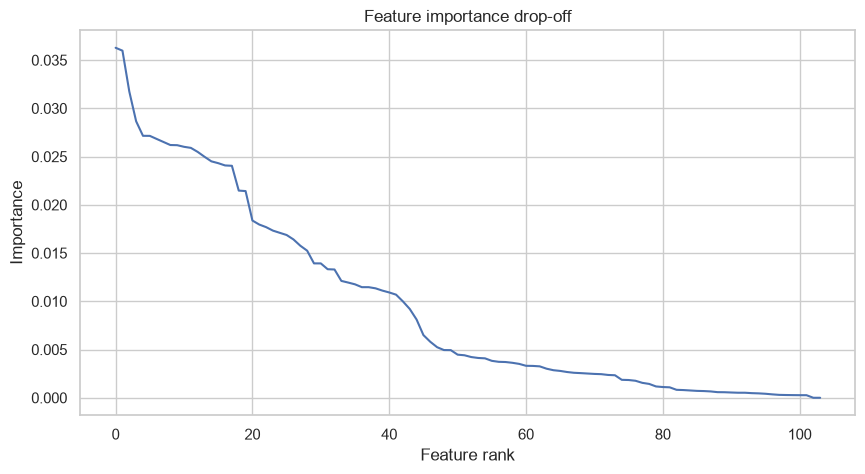

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(importances['importance'].values)
plt.xlabel('Feature rank')
plt.ylabel('Importance')
plt.title('Feature importance drop-off')
plt.show()

In [ ]:
# Add cumulative importance to see exactly how much signal you keep
importances_sorted = importances.sort_values('importance', ascending=False).reset_index(drop=True)
importances_sorted['cumulative_importance'] = importances_sorted['importance'].cumsum()

# See how many features you need to capture 95% of total importance
threshold = 0.95
n_features_95 = (importances_sorted['cumulative_importance'] <= threshold).sum() + 1
print(f"Features needed for {threshold*100}% of total importance: {n_features_95}")
# Get the list of selected feature names
selected_features = importances_sorted.head(n_features_95)['feature'].tolist()

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Features needed for 95.0% of total importance: 64
Selected 64 features:
['term', 'dti', 'loan_amnt', 'annual_inc', 'revol_util', 'bc_open_to_buy', 'tot_hi_cred_lim', 'avg_cur_bal', 'fico_avg', 'revol_bal', 'tot_cur_bal', 'open_acc_ratio', 'credit_age', 'total_bc_limit', 'total_rev_hi_lim', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_old_il_acct', 'mths_since_recent_bc', 'total_acc', 'earliest_cr_line_year', 'mths_since_recent_inq', 'mo_sin_rcnt_rev_tl_op', 'issue_d_month', 'earliest_cr_line_month', 'acc_open_past_24mths', 'mo_sin_rcnt_tl', 'num_bc_tl', 'open_acc', 'num_sats', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'num_op_rev_tl', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'num_bc_sats', 'all_util', 'issue_d_year', 'max_bal_bc', 'mort_acc', 'num_tl_op_past_12m', 'num_actv_bc_tl', 'total_bal_il', 'il_util', 'inq_last_6mths', 'open_rv_24m', 'inq_last_12m', 'num_accts_ever_120_pd', 'delinq_2yrs', 'open_act_il', 'total_cu_tl', 'verification_status_Verified', 'open_il_24m', 'home_ownership_REN

Conclusion: Instead of picking an arbitrary number of features, we used cumulative importance from the Random Forest to find how many features are needed to retain 95% of the model's total predictive signal. This gave us [n_features_95] features out of the original 104 — matching the natural elbow visible in the importance plot (a sharp drop in the first ~10 features, then a long flat tail of low-value ones). 
These selected features are saved to selected_features.json for use in modeling.ipynb.

## Save features and the engineered data in data/processed



In [35]:
import json

with open('../data/processed/selected_features.json', 'w') as f:
    json.dump(selected_features, f)

In [38]:
# Combine final engineered features + target for saving
train_engineered = X_train.copy()
train_engineered['loan_status'] = y_train

test_engineered = X_test.copy()
test_engineered['loan_status'] = y_test

train_engineered.to_csv('../data/processed/train_engineered.csv', index=False)
test_engineered.to_csv('../data/processed/test_engineered.csv', index=False)

print(f"Train engineered saved: {train_engineered.shape}")
print(f"Test engineered saved: {test_engineered.shape}")

Train engineered saved: (1093451, 105)
Test engineered saved: (273366, 105)


## Save the RF  model in models 

In [36]:
import joblib

joblib.dump(rf, '../models/rf_feature_selector.pkl')

['../models/rf_feature_selector.pkl']